### Lab 1: Knapsack Problem

Copyright **`(c)`** 2025 Giovanni Squillero `<giovanni.squillero@polito.it>`,
    [`https://github.com/squillero/computational-intelligence`](https://github.com/squillero/computational-intelligence),
    Free under certain conditions — see the [`license`](https://github.com/squillero/computational-intelligence/blob/master/LICENSE.md) for details.  

In [1]:
import numpy as np

In [29]:
NUM_KNAPSACKS = 2
NUM_ITEMS = 10
NUM_DIMENSIONS = 2

In [ ]:
VALUES = np.random.randint(0, 100, size=NUM_ITEMS)
WEIGHTS = np.random.randint(0, 100, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = np.random.randint(
    0, 100 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

In [46]:
CONSTRAINTS

array([614, 496])

In [32]:
# A random solution
solution = np.array(
    [np.random.random(NUM_ITEMS) < 0.5 for _ in range(NUM_KNAPSACKS)], dtype=np.bool
)

In [33]:
solution

array([[False, False, False,  True,  True, False, False, False, False,
        False],
       [False,  True,  True, False,  True,  True,  True,  True,  True,
        False]])

In [34]:

# Check that the same object does not appear in multiple knapsacks
np.all(solution.sum(axis=0) <= 1)

np.False_

In [35]:

# Check if the solution is valid
all_knapsacks = np.any(solution, axis=0)
np.all(WEIGHTS[all_knapsacks].sum(axis=0) < CONSTRAINTS)
print("Weights:", WEIGHTS[all_knapsacks].sum(axis=0))
print("Constraints:", CONSTRAINTS)

Weights: [405 419]
Constraints: [194  15]


## TEST PROBLEMS

In [179]:

# Problem 1:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 3
NUM_ITEMS = 20
NUM_DIMENSIONS = 2
VALUES = rng.integers(0, 100, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 100, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    0, 100 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

In [166]:
# Problem 2:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 10
NUM_ITEMS = 100
NUM_DIMENSIONS = 10
VALUES = rng.integers(0, 1000, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 1000, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    1000 * 2, 1000 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

In [79]:

# Problem 3:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 100
NUM_ITEMS = 5000
NUM_DIMENSIONS = 100
VALUES = rng.integers(0, 1000, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 1000, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    1000 * 10, 1000 * 2 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS))

## Solution

In [180]:
print(VALUES)

print(WEIGHTS)

print(CONSTRAINTS)

[ 8 77 65 43 43 85  8 69 20  9 52 97 73 76 71 78 51 12 83 45]
[[50 37]
 [18 92]
 [78 64]
 [40 82]
 [54 44]
 [45 22]
 [ 9 55]
 [88  6]
 [85 82]
 [27 63]
 [16 75]
 [70 35]
 [ 6 97]
 [44 89]
 [67 77]
 [75 19]
 [36 46]
 [49  4]
 [54 15]
 [74 68]]
[[614 496]
 [244 644]
 [273 216]]


In [181]:
# Generate a random initial solution
initial_solution = np.array(
    [rng.random(NUM_ITEMS) < 0.5 for _ in range(NUM_KNAPSACKS)], dtype=np.bool
)
initial_solution

array([[ True,  True,  True,  True,  True,  True, False,  True, False,
        False,  True, False, False,  True,  True, False,  True,  True,
         True, False],
       [False, False, False,  True, False,  True,  True, False,  True,
        False, False, False, False, False,  True,  True,  True,  True,
         True, False],
       [ True,  True,  True,  True, False, False, False, False,  True,
        False,  True,  True,  True, False,  True,  True, False,  True,
        False,  True]])

In [182]:
def check_solution(solution, debug = 0) -> bool:
    # Check that the same object does not appear in multiple knapsacks
    if not np.all(solution.sum(axis=0) <= 1):
        if debug:
            print("Invalid solution: same object appears in multiple knapsacks")
        return False

    total_weights = np.zeros((NUM_KNAPSACKS, NUM_DIMENSIONS), dtype=np.int32)
    # Check constraints for each knapsack individually
    for k in range(NUM_KNAPSACKS):
        items_in_knapsack = np.where(solution[k])[0]
        total_weights[k] = WEIGHTS[items_in_knapsack].sum(axis=0)

    if not np.all(total_weights < CONSTRAINTS):
        if debug:
            print("Invalid solution: knapsack constraints violated")
            print("Weights:", total_weights)
            print("Constraints:", CONSTRAINTS)
        return False

    return True

In [183]:
def tweak_solution(solution):
    new_solution = solution.copy()
    # Add an item to a random knapsack
    knapsack = np.random.randint(NUM_KNAPSACKS)
    item = np.random.randint(NUM_ITEMS)
    # Ensure the item is not already in another knapsack
    if not np.any(new_solution[:, item]):
            new_solution[knapsack, item] = True
    return new_solution

In [184]:
# Check that the same object does not appear in multiple knapsacks
if not np.all(initial_solution.sum(axis=0) <= 1):
    indices = np.where(initial_solution.sum(axis=0) > 1)[0]
    for i in indices:
        knapsacks = np.where(initial_solution[:, i])[0]
        to_remove = rng.choice(knapsacks, size=len(knapsacks) - 1, replace=False)
        initial_solution[to_remove, i] = False
np.all(initial_solution.sum(axis=0) <= 1)

total_weights = np.zeros((NUM_KNAPSACKS, NUM_DIMENSIONS), dtype=np.int32)
# Check constraints for each knapsack individually
for k in range(NUM_KNAPSACKS):
    items_in_knapsack = initial_solution[k]
    total_weights[k] = WEIGHTS[items_in_knapsack].sum(axis=0)


if not np.all(total_weights < CONSTRAINTS):
    print(f"solution  is not valid")
    print("Weights:", total_weights)
    print("Constraints:", CONSTRAINTS)
else:
    print(f"Knapsack is valid")

# we want to create a valid initial solution so we will remove items until the solution is valid
while not np.all(total_weights < CONSTRAINTS):
    # Find a knapsack that is not valid
    invalid_knapsacks = np.where(np.any(total_weights >= CONSTRAINTS, axis=1))[0]
    k = rng.choice(invalid_knapsacks)
    # Find items in the knapsack
    items_in_knapsack = np.where(initial_solution[k])[0]
    if len(items_in_knapsack) == 0:
        continue
    # Remove a random item from the knapsack
    item_to_remove = rng.choice(items_in_knapsack)
    initial_solution[k, item_to_remove] = False
    # Update total weights
    total_weights[k] = WEIGHTS[initial_solution[k]].sum(axis=0)


total_weights = np.zeros((NUM_KNAPSACKS, NUM_DIMENSIONS), dtype=np.int32)
# Check constraints for each knapsack individually
for k in range(NUM_KNAPSACKS):
    items_in_knapsack = initial_solution[k]
    total_weights[k] = WEIGHTS[items_in_knapsack].sum(axis=0)


if not np.all(total_weights < CONSTRAINTS):
    print(f"solution  is not valid")
    print("Weights:", total_weights)
    print("Constraints:", CONSTRAINTS)
else:
    print(f"Knapsack is valid")
    print("Weights:", total_weights)
    print("Constraints:", CONSTRAINTS)


solution  is not valid
Weights: [[337 297]
 [ 98 141]
 [523 571]]
Constraints: [[614 496]
 [244 644]
 [273 216]]
Knapsack is valid
Weights: [[337 297]
 [ 98 141]
 [ 91 179]]
Constraints: [[614 496]
 [244 644]
 [273 216]]


In [185]:
print(check_solution(initial_solution, debug=1))

initial_solution_values = np.sum(np.sum(initial_solution * VALUES, axis=1))

print("Initial solution values:", initial_solution_values)

# We can now use initial_solution as a valid starting point for our optimization algorithm
# We will only climb and accept only solution that are valid and better than the current solution
MAX_ITERATIONS = 100000
current_solution = initial_solution
current_solution_values = initial_solution_values

max_values = np.sum(VALUES)
print("Max values:", max_values)

for _ in range(MAX_ITERATIONS or current_solution_values == max_values):
    new_solution = tweak_solution(current_solution)
    if check_solution(new_solution):
        new_solution_values = np.sum(np.sum(new_solution * VALUES, axis=1))
        if new_solution_values > current_solution_values:
            current_solution = new_solution
            current_solution_values = new_solution_values
            #print("New best solution values:", current_solution_values)

print("Final solution values:", current_solution_values)

True
Initial solution values: 615
Max values: 1065
Final solution values: 940


## OK now we have a valid method we will try to improve it

we will map the knapstack in a different way, with just one list of size NUM_ITEMS
each position will contain the knapstack number where the item is placed, or -1 if not placed

we will introduce a new parameter, the "emptiness ratio", that is the percentage of knapstack left empty, this helps us decide if we want to add a new item or remove an existing one or move an item from one knapstack to another


In [201]:
# Problem 1:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 3
NUM_ITEMS = 20
NUM_DIMENSIONS = 2
VALUES = rng.integers(0, 100, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 100, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    0, 100 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

In [196]:
# Problem 2:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 10
NUM_ITEMS = 100
NUM_DIMENSIONS = 10
VALUES = rng.integers(0, 1000, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 1000, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    1000 * 2, 1000 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

In [191]:
# Problem 3:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 100
NUM_ITEMS = 5000
NUM_DIMENSIONS = 100
VALUES = rng.integers(0, 1000, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 1000, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    1000 * 10, 1000 * 2 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS))

In [202]:
def fitness(solution):
    total_value = 0
    total_weights = np.zeros((NUM_KNAPSACKS, NUM_DIMENSIONS), dtype=np.int32)

    for item, knapsack in enumerate(solution):
        if knapsack != -1:
            total_value += VALUES[item]
            total_weights[knapsack] += WEIGHTS[item]

    # Check constraints
    if np.any(total_weights > CONSTRAINTS):
        return -1, 0, 0  # Invalid solution

    return total_value, CONSTRAINTS - total_weights, np.min((CONSTRAINTS - total_weights) / CONSTRAINTS, axis=1)



In [203]:
def tweak_solution(solution, value):
    new_solution = solution.copy()
    
    mean_remaining_ratio = np.mean(value[2])
    if mean_remaining_ratio > 0.15:
        prob_add = 0.99
    else:
        prob_add = 0.65

    if np.random.rand() < prob_add:
        # Add an item to a random knapsack
        empty_items = np.where(new_solution == -1)[0]
        if len(empty_items) > 0:
            item = np.random.choice(empty_items)
            knapsack = np.random.randint(NUM_KNAPSACKS)
            new_solution[item] = knapsack

    else:
        # switch an item from one knapsack to another or remove it
        filled_items = np.where(new_solution != -1)[0]
        if len(filled_items) > 0:
            item = np.random.choice(filled_items)
            if np.random.rand() < 0.05:
                # remove it
                new_solution[item] = -1
            else:
                # switch it
                knapsack = new_solution[item]
                new_knapsack = (knapsack + np.random.randint(1, NUM_KNAPSACKS)) % NUM_KNAPSACKS
                new_solution[item] = new_knapsack
    new_value = fitness(new_solution)

    if new_value[0] != -1:
        return new_solution, new_value
    
    return solution, value

In [204]:
MAX_ITERATIONS = 50000

from IPython.display import display
import ipywidgets as widgets

initial_solution =np.full(NUM_ITEMS, -1, dtype=np.int32)  # -1 means not in any knapsack
value = fitness(initial_solution)

# we will save the best solution found and the value to print a graph at the end
best_solution = initial_solution
best_value = value

value_history = [value]

bar = widgets.IntProgress(min=0, max=MAX_ITERATIONS)
display(bar)
for i in range(MAX_ITERATIONS):
    initial_solution, value = tweak_solution(initial_solution, value)
    value_history.append(value)
    if value[0] > best_value[0]:
        best_solution = initial_solution
        best_value = value
    bar.value = i+1
    bar.description = f"{((i+1)/MAX_ITERATIONS)*100:.2f}%"




print(value[0])
print(best_value[0])

IntProgress(value=0, max=50000)

1065
1065


Theorical max: 1065


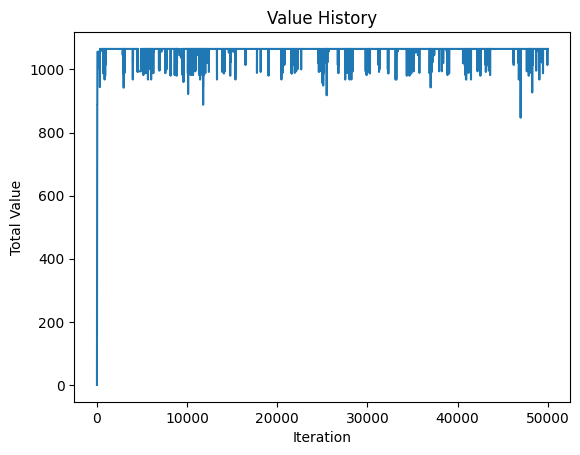

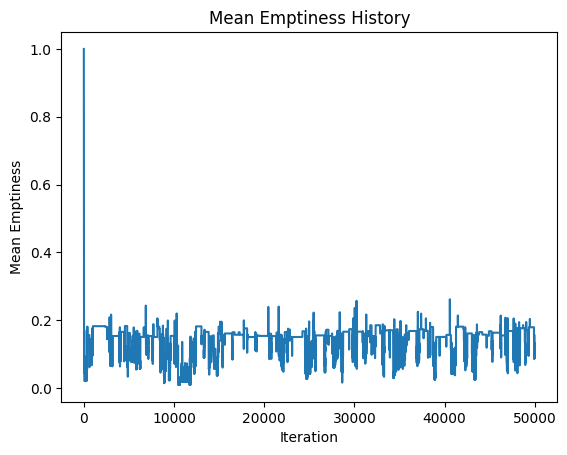

Best mean emptiness: 0.0554294709834107
Final mean emptiness: 0.13188395129167207


In [205]:
import matplotlib.pyplot as plt

theorical_max = np.sum(VALUES)
print("Theorical max:", theorical_max)


values = [v[0] for v in value_history]
plt.plot(range(len(value_history)), values)
plt.xlabel('Iteration')
plt.ylabel('Total Value')
plt.title('Value History')
plt.show()

mean_emptiness = [np.mean(v[2]) for v in value_history]
plt.figure()
plt.plot(range(len(value_history)), mean_emptiness)
plt.xlabel('Iteration')
plt.ylabel('Mean Emptiness')
plt.title('Mean Emptiness History')
plt.show()

best_mean_emptiness = np.mean(best_value[2])
print("Best mean emptiness:", best_mean_emptiness)
final_mean_emptiness = np.mean(value[2])
print("Final mean emptiness:", final_mean_emptiness)

## Conclusion
The new mapping is more compact and easier to manage. The mutation and crossover operations are simplified, leading to potentially better performance in finding optimal solutions. Further testing and tuning of the genetic algorithm parameters may yield even better results.

As we are checking a lot of parameters, this solution is slower than the previous one, but is more effective. 

with 50000 iterations
PB 1: solution 1065, theoretical maximum 1065, time 10.7s
PB 2: solution 45194, theoretical maximum 52620, time 15.0s
PB 3: solution 1320226, theoretical maximum 2490698, time 3m 5.0s